**Objective** -- This notebook builds an end-to-end sklearn pipeline to classify countries into three development tiers Developed, Mid Developed, and Low Development based on socio-economic indicators like child mortality, income, and life expectancy, so that aid and resources can be directed to the countries that need them most.

**Dataset** -- Unsupervised Learning on Country Data(Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
cnty_data = pd.read_csv("Country-data.csv")
cnty_data.columns = cnty_data.columns.str.strip()
cnty_data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Shape, Size and Basic Info of data

In [3]:
print(cnty_data.shape,end='\n\n')
print(cnty_data.isnull().sum(),end='\n\n')
print(cnty_data.duplicated().sum(),end='\n\n')
print(cnty_data.dtypes)

(167, 10)

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

0

country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


In [4]:
numcols = ["child_mort", "exports", "health", "imports","income", "inflation", "life_expec", "total_fer", "gdpp"]
catcols = ["country"]

Skewness and Kurtosis analysis

In [6]:
for col in numcols:
  skew = cnty_data[col].skew()
  kurt=cnty_data[col].kurt()
  print(f"{col} skewness is {skew} and kurtosis is {kurt}")

child_mort skewness is 1.4507735387555047 and kurtosis is 1.76688194174872
exports skewness is 2.4458240051613496 and kurtosis is 10.138666385575297
health skewness is 0.7057460547100981 and kurtosis is 0.6941956045730078
imports skewness is 1.90527571988626 and kurtosis is 6.755854282819444
income skewness is 2.231479607767527 and kurtosis is 7.02865707170062
inflation skewness is 5.154049359697971 and kurtosis is 41.74250190710696
life_expec skewness is -0.9709955819991258 and kurtosis is 1.1515912411574836
total_fer skewness is 0.9670916808050207 and kurtosis is -0.18677901913186368
gdpp skewness is 2.2180514519497163 and kurtosis is 5.527890806297906


Almost all features are positively skewed meaning most countries have low values but a few extreme ones pull the distribution to the right, with inflation being the most extreme case having a skewness of 5.15 and kurtosis of 41.74. This confirms that outlier handling through winsorization is necessary before feeding the data into our clustering pipeline.

Histograms (The histograms confirm what the skewness numbers told us)

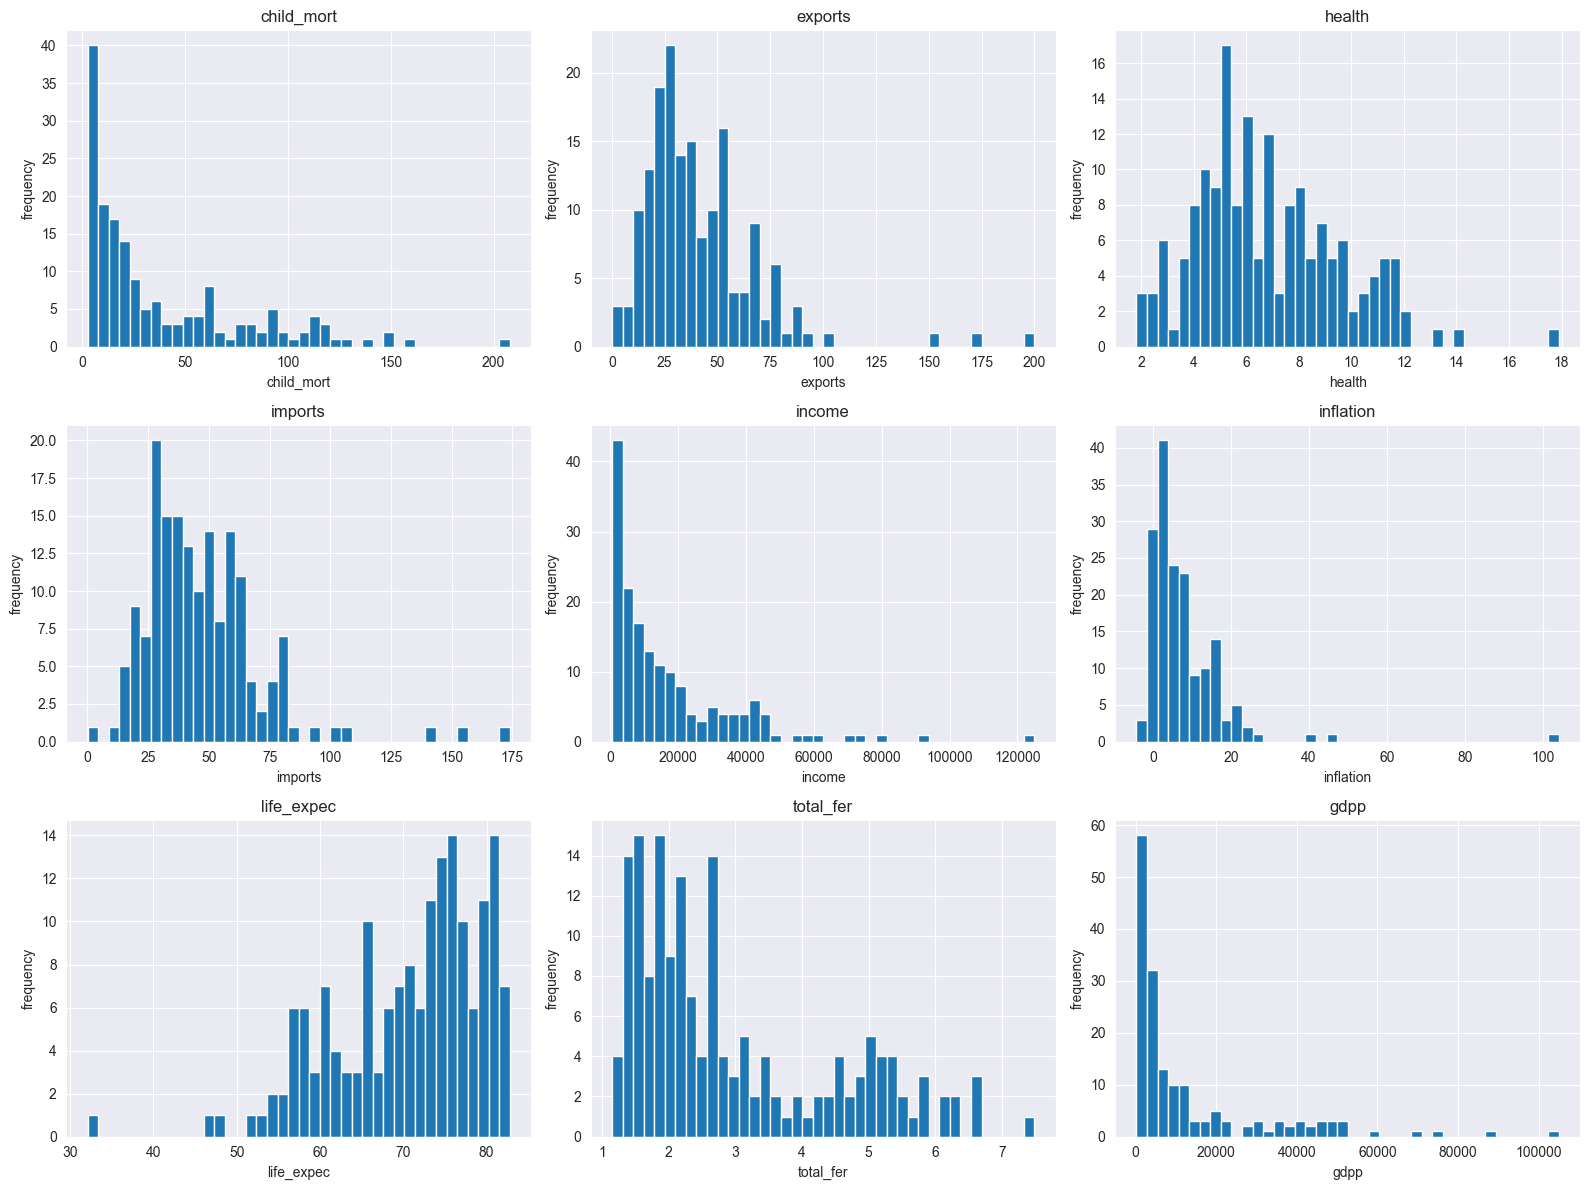

In [7]:
fig, axes = plt.subplots(3,3,figsize=(16,12))
axes = axes.flatten()
for i,col in enumerate(numcols):
  axes[i].hist(cnty_data[col],bins=40,edgecolor = 'white')
  axes[i].set_title(col)
  axes[i].set_xlabel(col)
  axes[i].set_ylabel("frequency")
plt.tight_layout()
plt.show()

Boxplots (Boxplots give us a clearer picture of where the outliers actually sit)

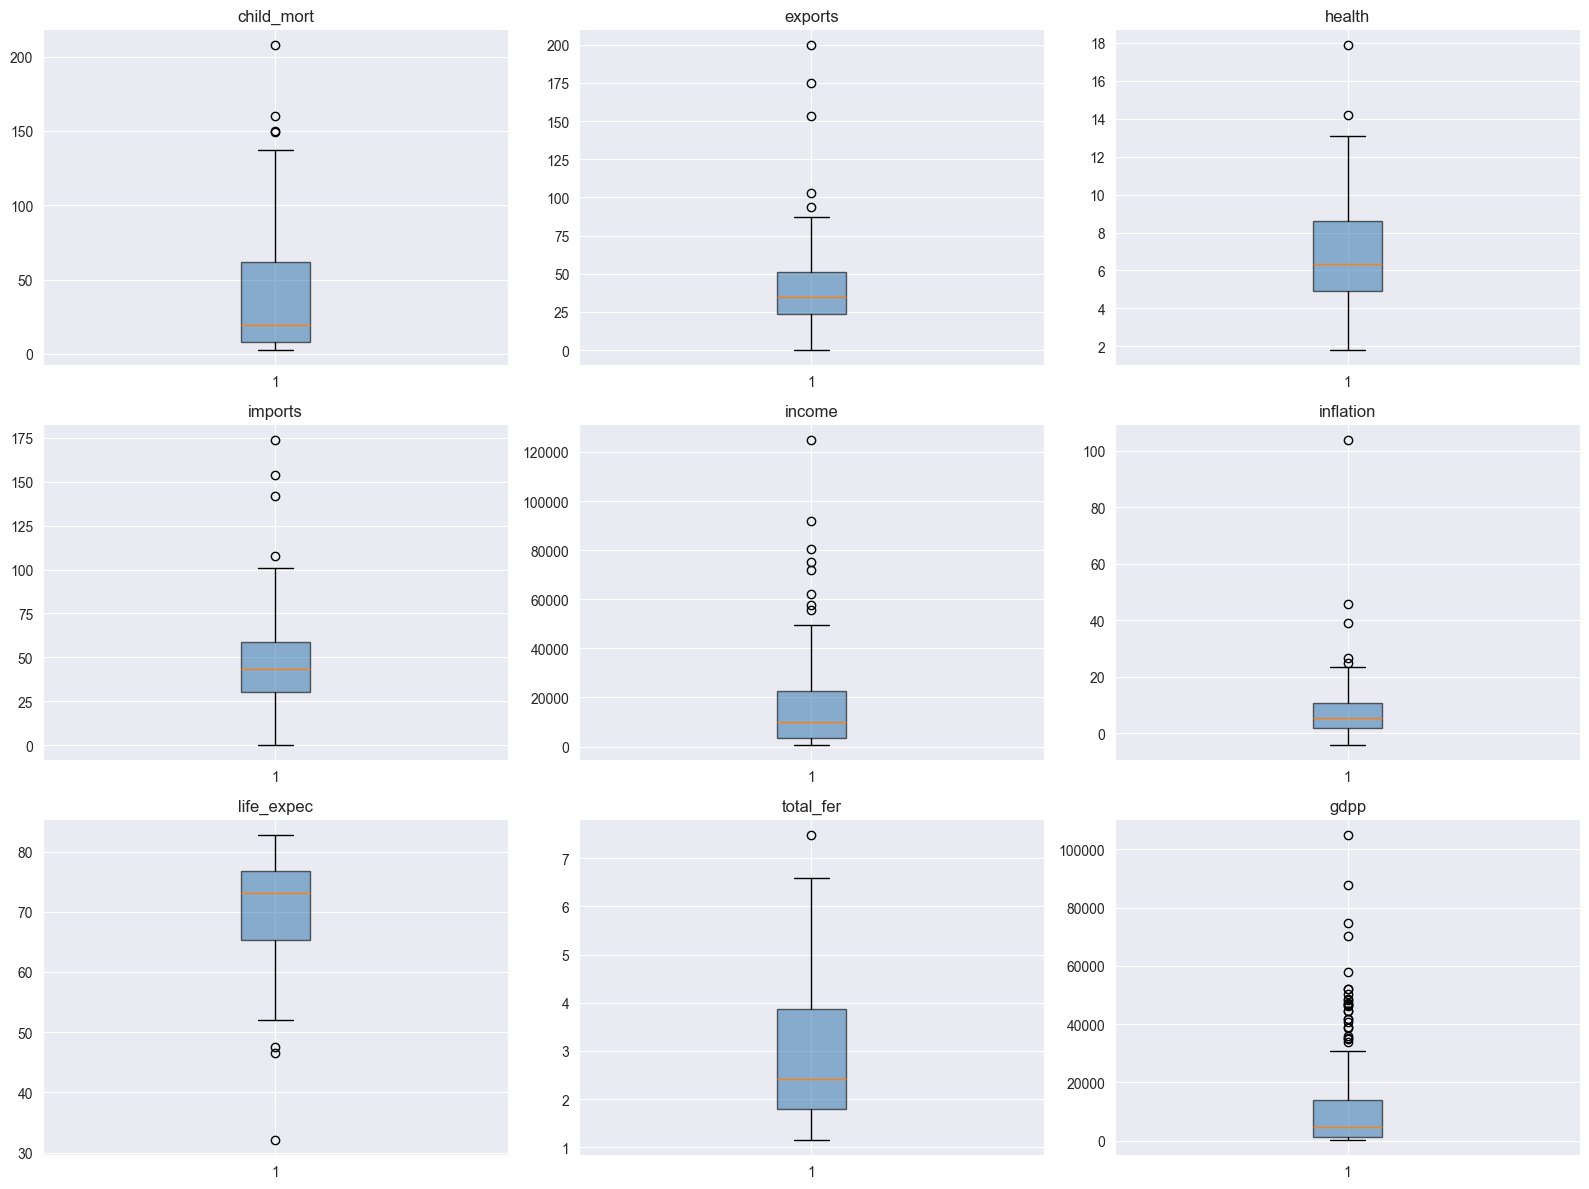

In [8]:
fig,axes =plt.subplots(3,3,figsize=(16,12))
axes = axes.flatten()
for i,col in enumerate(numcols):
  axes[i].boxplot(cnty_data[col], patch_artist=True, boxprops={'facecolor': 'steelblue','alpha':0.6})
  axes[i].set_title(col)
plt.tight_layout()
plt.show()

Correlation matrix

In [9]:
cnty_data[numcols].corr()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


Custom Winsorizer Class

In [10]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        x=pd.DataFrame(x)
        self.lower=x.quantile(0.01)
        self.upper= x.quantile(0.99)
        return self

    def transform(self, x):
        x =pd.DataFrame(x).copy()
        return x.clip(lower=self.lower, upper=self.upper, axis=1)

In [11]:
x=cnty_data[numcols]
x.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Elbow trick to find the optimal k

In [12]:
pipeline1 = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('winsorizer', Winsorizer()),
    ('scaler',     StandardScaler())
])

xscaled =pipeline1.fit_transform(x)
inertiavalues=[]
k_range =range(2,11)

for k in k_range:
    km =KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(xscaled)
    inertiavalues.append(km.inertia_)
    print(f"k={k} and inertia= {km.inertia_:.2f}")


k=2 and inertia= 1025.30
k=3 and inertia= 801.63
k=4 and inertia= 701.46
k=5 and inertia= 604.33
k=6 and inertia= 551.28
k=7 and inertia= 491.04
k=8 and inertia= 456.89
k=9 and inertia= 418.14
k=10 and inertia= 394.90


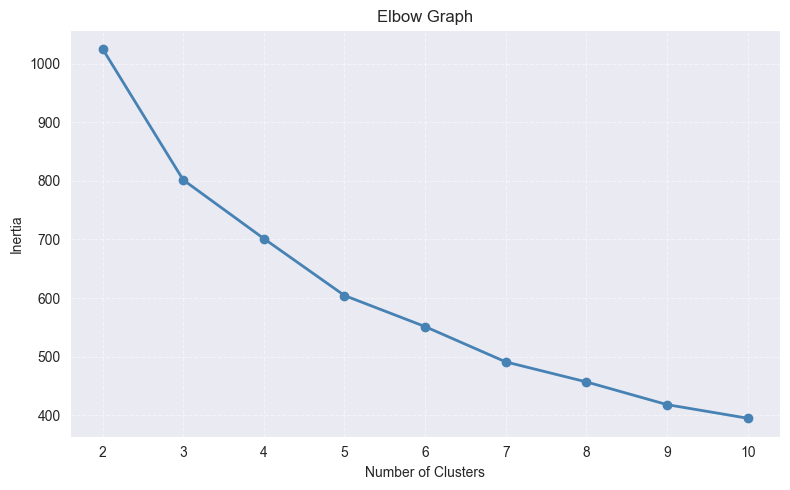

In [13]:
plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertiavalues, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Graph")
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Final Pipeline

In [14]:
best_k = 3
pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('winsorizer',Winsorizer()),
    ('scaler', StandardScaler()),
    ('kmeans',KMeans(n_clusters=best_k,random_state=42,n_init=10))])
pipeline.fit(x)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('winsorizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['child_mort','exports','health',...,'life_expec','total_fer','gdpp']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types

Cluster Assignment and Silhouette Score

In [15]:
cnty_data['cluster'] = pipeline.predict(x)
score = silhouette_score(xscaled,cnty_data['cluster'])
print(f"Silhouette Score for k value k={best_k} {score:.4f}")
print(cnty_data['cluster'].value_counts().sort_index())

Silhouette Score for k value k=3 0.2801
cluster
0    36
1    84
2    47
Name: count, dtype: int64


DBSCAN Initial Run

In [16]:
dbscan = DBSCAN(eps=1.5,min_samples=5)
dbscan_labels = dbscan.fit_predict(xscaled)
cnty_data['dbscan_cluster'] = dbscan_labels
cluster_counts = pd.Series(dbscan_labels).value_counts()
n_clusters = len(cluster_counts.drop(index=-1, errors='ignore'))
n_noise=list(dbscan_labels).count(-1)

print(f"DBSCAN clusters found {n_clusters}")
print(f"Noise points (-1) {n_noise}")
print("\nDistribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN clusters found 1
Noise points (-1) 38

Distribution:
-1     38
 0    129
Name: count, dtype: int64


DBSCAN Grid Search Here only One cluster is found in Dbscan So we need to optime it



In [17]:
results = []
for eps in [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    for min_s in [3, 4, 5, 7, 10]:
        labels = DBSCAN(eps=eps, min_samples=min_s).fit_predict(xscaled)

        n_clusters = len(set(labels))-(1 if -1 in labels else 0)
        n_noise= list(labels).count(-1)
        if n_clusters >= 2:
            score = silhouette_score(xscaled,labels)
        else:
            score = -999

        results.append({
            'eps': eps, 'min_samples': min_s,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': round(score, 4)
        })

res_df = pd.DataFrame(results)
valid = res_df[res_df['n_clusters'] >=2].sort_values('silhouette', ascending=False)
print(valid.head(10).to_string(index=False))

 eps  min_samples  n_clusters  n_noise  silhouette
 1.5            7           2       42      0.1917
 1.5           10           2       50      0.1782
 2.0            3           2       11      0.1440
 1.2            4           3       64      0.1174
 1.2            3           4       56      0.1065
 1.2           10           2      108      0.0513
 1.2            5           4       70      0.0314
 1.2            7           3       85      0.0211
 1.5            4           2       32      0.0017
 1.0            4           3      102     -0.0117


In [18]:
best = valid.iloc[0]
print(f"Best eps={best['eps']}, min_samples={best['min_samples']}")
print(f"Clusters: {best['n_clusters']}, Noise: {best['n_noise']}, Silhouette: {best['silhouette']}")

dbscan = DBSCAN(eps=best['eps'], min_samples=int(best['min_samples']))
dbscan_labels = dbscan.fit_predict(xscaled)
cnty_data['dbscan_cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise    = list(dbscan_labels).count(-1)
print(f"\nDBSCAN clusters found {n_clusters}")
print(f"Noise points (-1) {n_noise}")
print("\nDistribution")
print(pd.Series(dbscan_labels).value_counts().sort_index())

Best eps=1.5, min_samples=7.0
Clusters: 2.0, Noise: 42.0, Silhouette: 0.1917

DBSCAN clusters found 2
Noise points (-1) 42

Distribution
-1     42
 0     23
 1    102
Name: count, dtype: int64


Comparision of both model kmeans and DBSCAN

In [19]:
kmeans_score = silhouette_score(xscaled, cnty_data['cluster'])
dbscan_score = silhouette_score(xscaled, dbscan_labels)
print(f"KMeans Silhouette {kmeans_score:.4f}")
print(f"DBSCAN Silhouette {dbscan_score:.4f}")

KMeans Silhouette 0.2801
DBSCAN Silhouette 0.1917


KMeans achieved a silhouette score of 0.2801 compared to DBSCAN at 0.1917, confirming that KMeans is better suited for this dataset

 PCA Visualization

Variance explained PC1 47.25% PC2 16.90% Total 64.15%


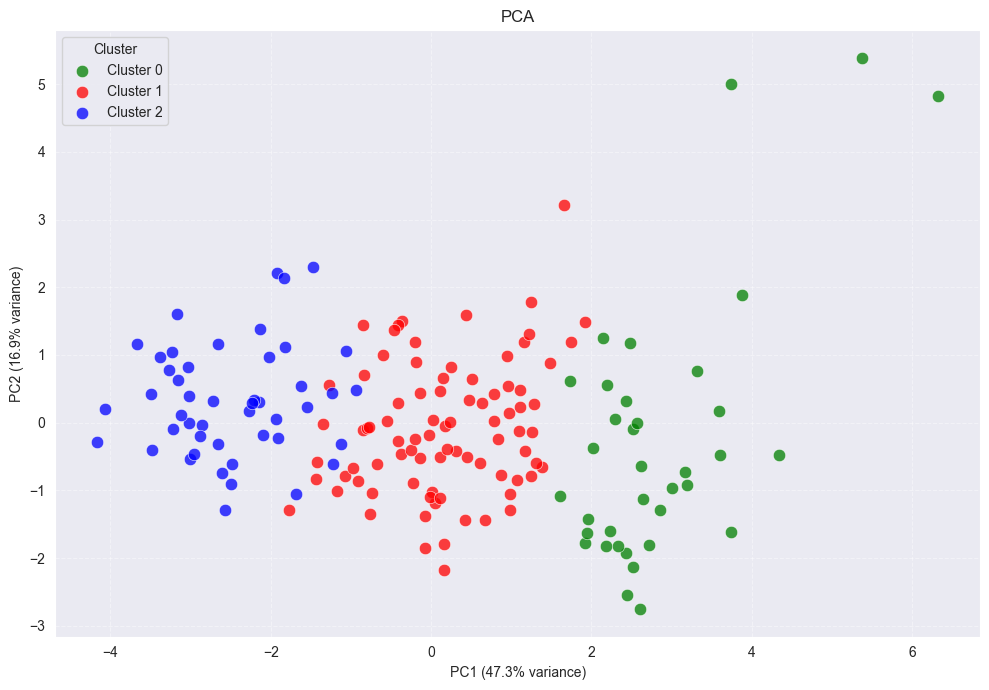

In [20]:
pca = PCA(n_components=2,random_state=42)
xpca = pca.fit_transform(xscaled)
ev = pca.explained_variance_ratio_
print(f"Variance explained PC1 {ev[0]:.2%} PC2 {ev[1]:.2%} Total {sum(ev):.2%}")
colors = {0:'green', 1:'red', 2:'blue'}
plt.figure(figsize=(10, 7))
for cid in sorted(cnty_data['cluster'].unique()):
    mask = cnty_data['cluster']==cid
    plt.scatter(xpca[mask, 0], xpca[mask, 1],c=colors[cid], label=f"Cluster {cid}",alpha=0.75, edgecolors='white', linewidth=0.5, s=80)

plt.xlabel(f"PC1 ({ev[0]:.1%} variance)")
plt.ylabel(f"PC2 ({ev[1]:.1%} variance)")
plt.title("PCA")
plt.legend(title="Cluster")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Cluster Summary Table

In [21]:
summary = cnty_data.groupby('cluster')[numcols].mean().round(2)
print(summary.T.to_string())

cluster            0         1        2
child_mort      5.00     21.93    92.96
exports        58.74     40.24    29.15
health          8.81      6.20     6.39
imports        51.49     47.47    42.32
income      45672.22  12305.60  3942.40
inflation       2.67      7.60    12.02
life_expec     80.13     72.81    59.19
total_fer       1.75      2.31     5.01
gdpp        42494.44   6486.45  1922.38


In [22]:
summary.T.style.background_gradient(cmap='RdYlGn', axis=1)

cluster,0,1,2
child_mort,5.000000,21.930000,92.960000
exports,58.740000,40.240000,29.150000
health,8.810000,6.200000,6.390000
imports,51.490000,47.470000,42.320000
income,45672.220000,12305.600000,3942.400000
inflation,2.670000,7.600000,12.020000
life_expec,80.130000,72.810000,59.190000
total_fer,1.750000,2.310000,5.010000
gdpp,42494.440000,6486.450000,1922.380000


Predict Function

In [24]:
def predict_cluster(user_input: dict) -> int:
    row = {col: np.nan for col in numcols}
    for key, val in user_input.items():
        if key in numcols:
            row[key] = val

    input_df = pd.DataFrame([row], columns=numcols)
    cluster = pipeline.predict(input_df)[0]
    cluster_labels = {
      0: "Developed",
      1: "Mid Developed",
      2: "Low Development"
}

    print(f"Predicted Cluster {cluster}")
    print(f"Cluster Type {cluster_labels.get(cluster, 'Unknown')}")
    return cluster

 Test Cases

In [25]:
predict_cluster({'child_mort':90,'exports':10,'health':3,'imports':15,
                 'income':1500,'inflation':12,'life_expec':55,
                 'total_fer':5.2,'gdpp':1200})

predict_cluster({'income': 45000, 'gdpp': 38000, 'life_expec': 79})

predict_cluster({'child_mort': 999, 'income': -5000, 'gdpp': 150000})

Predicted Cluster 2
Cluster Type Low Development
Predicted Cluster 0
Cluster Type Developed
Predicted Cluster 0
Cluster Type Developed


np.int32(0)

Observation 1 - Cluster 2 is the high mortality and low development group where child mortality is as high as 92.96, life expectancy is only 59 years, income is around 3942, and total fertility rate is 5.01. These countries need the most urgent humanitarian aid and healthcare investment.

Observation 2 - Cluster 0 represents the top tier economic zone where GDP per capita is 42494, income is 45672, child mortality is near zero at 5, and life expectancy is 80 years. These are the most prosperous and developed nations in the dataset.

Observation 3 - Cluster 1 sits in the middle ground with moderate income of 12305 and GDP per capita of 6486, a child mortality of 21.93, and life expectancy of 72.81 years. These are transitioning economies that are improving but still have room to grow in healthcare and economic output.

Observation 4 - Inflation tells an interesting story. Cluster 2 countries have the highest inflation at 12.02 while Cluster 0 developed nations have a very stable inflation of just 2.67, suggesting that economic instability and underdevelopment go hand in hand.

Observation 5 - Cluster 0 countries also lead in exports at 58.74 and imports at 51.49 indicating strong global trade participation, while Cluster 2 countries have the lowest exports at 29.15 which reflects their limited economic integration with the rest of the world.